In [4]:
# Install the required libraries
!pip install pyspark findspark nltk textblob wordcloud gensim plotly dash altair

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 26.7 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 15.5 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.10.0 requires tensorflow==2.17.0, but you have tensorflow 2.17.1 which is incompatible.


In [7]:
# Import required libraries
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, count, when, lit, udf
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType, BooleanType
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [8]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [61]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, udf
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

# Initialize Spark Session
spark = SparkSession.builder.appName("RealTimePipeline").getOrCreate()

# Define schema
schema = StructType([
    StructField("ID", IntegerType(), True),
    StructField("realId", StringType(), True),
    StructField("code", StringType(), True),
    StructField("pragma", StringType(), True),
    StructField("label_para", IntegerType(), True),
    StructField("label_function_call", IntegerType(), True),
    StructField("label_nested_loop", IntegerType(), True),
    StructField("label_reduction", IntegerType(), True),
    StructField("label_task", IntegerType(), True),
    StructField("label_simd", IntegerType(), True),
    StructField("label_target", IntegerType(), True)
])

# Load dataset
df = spark.read.json("/kaggle/input/omp-serial/omp_serial.json", schema=schema)

# Show first few rows
df.show(5)


+---+--------------------+--------------------+--------------------+----------+-------------------+-----------------+---------------+----------+----------+------------+
| ID|              realId|                code|              pragma|label_para|label_function_call|label_nested_loop|label_reduction|label_task|label_simd|label_target|
+---+--------------------+--------------------+--------------------+----------+-------------------+-----------------+---------------+----------+----------+------------+
|  1|fusiled_large-gra...|for (int i = 0; i...|    omp parallel for|         1|                  0|                0|              0|         0|         0|           0|
|  2|sharanyansrikanth...|for (int i = 0; i...|                NULL|         0|                  0|                0|              0|         0|         0|           0|
|  3|rose-compiler_ros...|for (i = 0; i < n...|omp parallel for ...|         1|                  0|                1|              0|         0|         0|

In [62]:
# Drop duplicates
df = df.dropDuplicates()

# Count missing values in each column
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

# Fill missing values (if applicable)
df = df.fillna({'pragma': 'unknown'})

# Standardizing Text Data (Convert text to lowercase)
df = df.withColumn("code", col("code").cast("string"))

df.show(5)


+---+------+----+------+----------+-------------------+-----------------+---------------+----------+----------+------------+
| ID|realId|code|pragma|label_para|label_function_call|label_nested_loop|label_reduction|label_task|label_simd|label_target|
+---+------+----+------+----------+-------------------+-----------------+---------------+----------+----------+------------+
|  0|     0|   0| 15221|         0|                  0|                0|              0|         0|         0|           0|
+---+------+----+------+----------+-------------------+-----------------+---------------+----------+----------+------------+

+----+--------------------+--------------------+--------------------+----------+-------------------+-----------------+---------------+----------+----------+------------+
|  ID|              realId|                code|              pragma|label_para|label_function_call|label_nested_loop|label_reduction|label_task|label_simd|label_target|
+----+--------------------+-------

In [63]:
from pyspark.sql.functions import mean, stddev

# Calculate mean & std dev
stats = df.select(
    mean(col("label_para")).alias("mean_para"),
    stddev(col("label_para")).alias("std_para")
).collect()[0]

# Define threshold (e.g., Z-score > 3)
mean_para, std_para = stats["mean_para"], stats["std_para"]
threshold = 3

# Flag anomalies
df = df.withColumn("is_anomaly", (col("label_para") - mean_para) / std_para > threshold)

df.show(5)


+----+--------------------+--------------------+--------------------+----------+-------------------+-----------------+---------------+----------+----------+------------+----------+
|  ID|              realId|                code|              pragma|label_para|label_function_call|label_nested_loop|label_reduction|label_task|label_simd|label_target|is_anomaly|
+----+--------------------+--------------------+--------------------+----------+-------------------+-----------------+---------------+----------+----------+------------+----------+
| 398|shashankheda_algo...|for (iter = 0; it...|omp parallel for ...|         1|                  1|                0|              0|         0|         0|           0|     false|
| 405|textfox_jacobi_op...|for (row = 0; row...|omp parallel for ...|         1|                  0|                1|              0|         0|         0|           0|     false|
| 436|sherrerap_OpenMPI...|for (i = 3; i < 4...|omp parallel for ...|         1|               

In [64]:
df.describe().show()


+-------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+-------------------+-------------------+--------------------+-------------------+-------------------+
|summary|               ID|              realId|                code|              pragma|        label_para|label_function_call|  label_nested_loop|    label_reduction|          label_task|         label_simd|       label_target|
+-------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+-------------------+-------------------+--------------------+-------------------+-------------------+
|  count|            32570|               32570|               32570|               32570|             32570|              32570|              32570|              32570|               32570|              32570|              32570|
|   mean|          16285.5|                NULL|                NULL|       

In [18]:
df.groupBy("pragma").count().orderBy(col("count").desc()).show()


+--------------------+-----+
|              pragma|count|
+--------------------+-----+
|             unknown|15221|
|    omp parallel for| 2654|
|omp parallel for ...|  249|
|omp parallel for ...|  204|
|omp parallel for ...|  170|
|omp parallel for ...|  170|
|omp parallel for ...|  168|
|omp parallel for ...|  168|
|omp parallel for ...|  168|
|omp parallel for ...|  154|
|omp parallel for ...|  136|
|omp parallel for ...|  130|
|omp parallel for ...|  128|
|omp parallel for ...|  128|
|omp parallel for ...|  118|
|omp parallel for ...|  116|
|omp parallel for ...|  106|
|omp parallel for ...|  100|
|omp parallel for ...|   96|
|omp parallel for ...|   96|
+--------------------+-----+
only showing top 20 rows



In [19]:
#Text Analysis 
from pyspark.sql.functions import explode, split

# Tokenize code into words
df_words = df.select(explode(split(col("code"), "\\s+")).alias("word"))

# Count word occurrences
df_words.groupBy("word").count().orderBy(col("count").desc()).show(10)


+----+-----+
|word|count|
+----+-----+
|   =|95099|
| for|49900|
|   <|45232|
|  0;|43205|
|   {|42425|
|   +|42019|
|   }|36252|
|   i|34681|
|   *|31827|
|  (i|25490|
+----+-----+
only showing top 10 rows



In [74]:
print(df_pd.columns)  # Check column names
print(df_pd.head())   # Display first few rows


Index(['label_para'], dtype='object')
   label_para
0           1
1           1
2           1
3           1
4           1


In [83]:
from pyspark.sql.functions import col, when
import plotly.express as px

# Add sentiment column BEFORE converting to Pandas
df = df.withColumn("sentiment", when(col("label_para") == 1, "positive")
                                .when(col("label_function_call") == 1, "neutral")
                                .otherwise("negative"))

# Convert to Pandas AFTER sentiment column is added
df_pd = df.toPandas()

# Plot Sentiment Distribution
fig = px.pie(df_pd, names="sentiment", title="Effieciency Analysis Based on Labels")
fig.show()


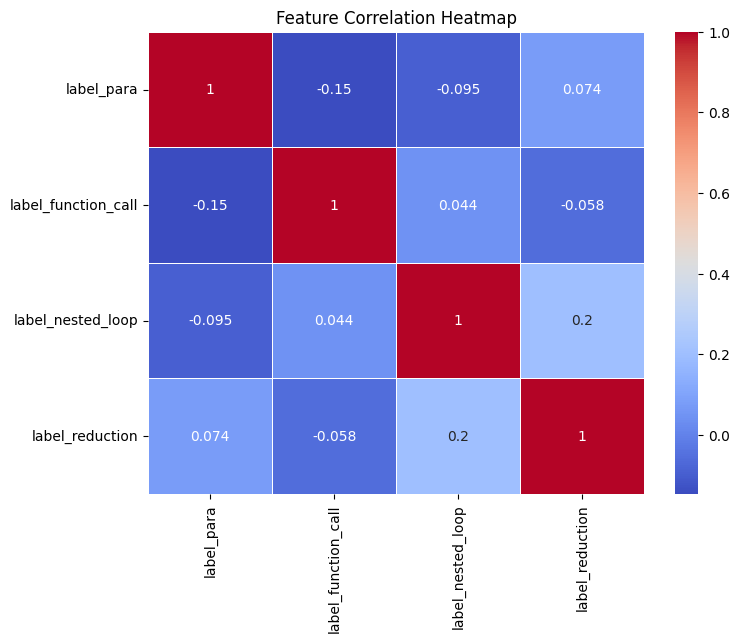

In [79]:
import seaborn as sns

# Compute correlation
correlation_matrix = df_pd[["label_para", "label_function_call", "label_nested_loop", "label_reduction"]].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [80]:
fig = px.scatter(df_pd, x="label_para", y="label_function_call", 
                 color="sentiment",
                 title="Relationship Between label_para & label_function_call")

fig.show()


In [23]:
#corelation b/w features 
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# Assemble features into a single vector
vector_col = "features"
assembler = VectorAssembler(inputCols=["label_para", "label_function_call", "label_nested_loop"], outputCol=vector_col)
df_vector = assembler.transform(df).select(vector_col)

# Compute correlation matrix
corr_matrix = Correlation.corr(df_vector, vector_col)
corr_matrix.show(truncate=False)



+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|pearson(features)                                                                                                                                                                                         |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1.0                   -0.14663664084879624  -0.09491398951803016  \n-0.14663664084879624  1.0                   0.04427212988029244   \n-0.09491398951803016  0.04427212988029244   1.0                   |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [45]:
!pip install plotly
import plotly.express as px
import pandas as pd
df_pd = df.toPandas()


In [31]:
top_pragma = pragma_counts.head(20)  # Show only top 20 categories

fig = px.bar(top_pragma, 
             x='pragma', 
             y='count', 
             title="Top 20 Most Common Pragma Directives",
             labels={'pragma': 'Pragma Directive', 'count': 'Count'},
             color='count')

fig.show()


In [32]:
#shortttttt sample
sample_data = pd.DataFrame({'pragma': ['omp parallel', 'omp for', 'omp task', 'omp for', 'omp task']})
sample_counts = sample_data['pragma'].value_counts().reset_index()
sample_counts.columns = ['pragma', 'count']

fig = px.bar(sample_counts, x='pragma', y='count', title="Test Pragma Chart")
fig.show()


In [69]:
fig = px.box(df_pd, x="label_para", title="Box Plot for Label Para (Outlier Detection)")
fig.show()


In [68]:
import plotly.express as px

# Convert PySpark DataFrame to Pandas
df_pd = df.select("label_para").toPandas()

# Compute label counts
label_counts = df_pd["label_para"].value_counts(normalize=True) * 100

# Convert Series to DataFrame
label_counts_df = label_counts.reset_index()
label_counts_df.columns = ["label_para", "count"]

# Plot
fig = px.bar(label_counts_df, 
             x="label_para", 
             y="count", 
             title="Label Para Distribution (%)",
             labels={"label_para": "Label", "count": "Percentage"},
             color="count")

fig.show()


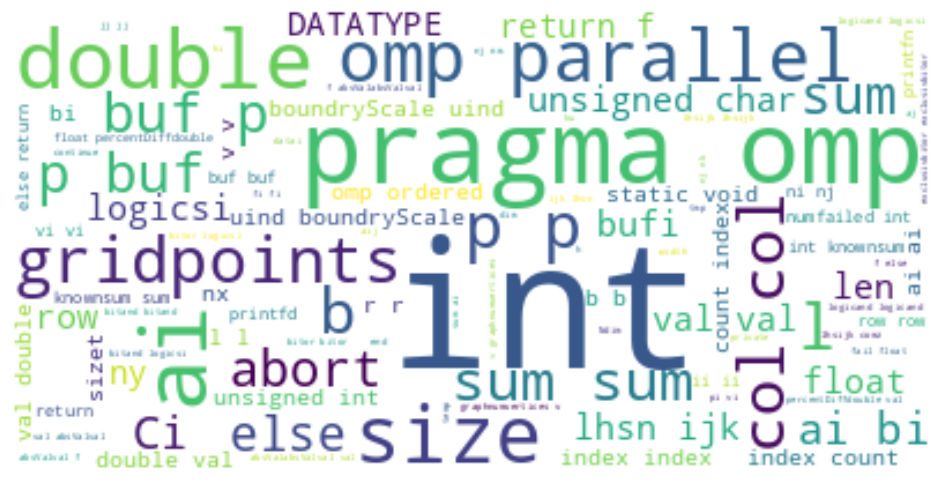

In [85]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import re

# Convert PySpark DataFrame to Pandas (Use 'code' column instead of 'review_column')
df_pd = df.select("code").toPandas()

# Drop missing values
df_pd = df_pd.dropna()

# Convert column to a single text string
text_data = " ".join(df_pd["code"].astype(str))

# Remove non-alphabetic characters (optional)
text_data = re.sub(r"[^a-zA-Z\s]", "", text_data)

# Set up stopwords
stop_words = set(stopwords.words("english"))

# Generate WordCloud
wordcloud = WordCloud(stopwords=stop_words, background_color="white", width=800, height=400).generate(text_data)

custom_stopwords = set(["n", "j", "c", "k", "x"])  # Add words to remove
wordcloud = WordCloud(stopwords=stop_words.union(custom_stopwords), background_color="white").generate(text_data)


# Plot the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()



In [84]:
from pyspark.sql.functions import col, length, avg

# Query 1: Total number of records in the dataset
total_records = df.count()
print("Total records:", total_records)

# Query 2: Count records where 'pragma' is not null (i.e. available)
non_null_pragma = df.filter(col("pragma").isNotNull()).count()
print("Records with non-null pragma:", non_null_pragma)

# Query 3: Top 5 most common 'pragma' directives with their counts
print("Top 5 'pragma' directives:")
df.groupBy("pragma").count().orderBy(col("count").desc()).show(5)

# Query 4: Average length of the 'code' column (number of characters)
print("Average code length:")
df.withColumn("code_length", length(col("code")))\
  .agg(avg("code_length").alias("avg_code_length")).show()

# Query 5: Count of records with label_para = 1 (e.g., indicating parallelism)
parallel_records = df.filter(col("label_para") == 1).count()
print("Records with label_para = 1:", parallel_records)

# Query 6: Show first 5 records where there is a nested loop (label_nested_loop = 1)
print("Records with nested loops (label_nested_loop = 1):")
df.filter(col("label_nested_loop") == 1).show(5)

# Query 7: Group by 'label_reduction' and count occurrences for each category
print("Count by label_reduction:")
df.groupBy("label_reduction").count().orderBy(col("count").desc()).show()

# Query 8: Aggregate average of all numeric label columns for an overall view
print("Average values for all numeric label columns:")
df.agg(
    avg("label_para").alias("avg_label_para"),
    avg("label_function_call").alias("avg_label_function_call"),
    avg("label_nested_loop").alias("avg_label_nested_loop"),
    avg("label_reduction").alias("avg_label_reduction"),
    avg("label_task").alias("avg_label_task"),
    avg("label_simd").alias("avg_label_simd"),
    avg("label_target").alias("avg_label_target")
).show()


Total records: 32570
Records with non-null pragma: 32570
Top 5 'pragma' directives:
+--------------------+-----+
|              pragma|count|
+--------------------+-----+
|             unknown|15221|
|    omp parallel for| 2654|
|omp parallel for ...|  249|
|omp parallel for ...|  204|
|omp parallel for ...|  170|
+--------------------+-----+
only showing top 5 rows

Average code length:
+------------------+
|   avg_code_length|
+------------------+
|153.50942585201105|
+------------------+

Records with label_para = 1: 17349
Records with nested loops (label_nested_loop = 1):
+----+--------------------+--------------------+--------------------+----------+-------------------+-----------------+---------------+----------+----------+------------+----------+---------+
|  ID|              realId|                code|              pragma|label_para|label_function_call|label_nested_loop|label_reduction|label_task|label_simd|label_target|is_anomaly|sentiment|
+----+--------------------+--------